In [1]:
# ! source get_paths.sh web sf_curr

In [2]:
import os
os.environ['DATASET_PATH'] = '/shared/john/model_training/'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


In [3]:
import os 
import argparse
import torch
import os
from omegaconf import OmegaConf
from tqdm import tqdm
from torchvision import transforms
from torchvision.io import write_video
from einops import rearrange
import torch.distributed as dist
from torch.utils.data import DataLoader, SequentialSampler
from torch.utils.data.distributed import DistributedSampler

from pipeline import (
    CausalDiffusionInferencePipeline,
    CausalInferencePipeline,
    ProgressiveCausalInferencePipeline,
    BidirectionalDiffusionInferencePipeline
)
from utils.dataset import TextDataset, TextImagePairDataset
from utils.misc import set_seed

from demo_utils.memory import gpu, get_cuda_free_memory_gb, DynamicSwapInstaller

/shared/miniconda3/envs/self_forcing/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
parser = argparse.ArgumentParser()
parser.add_argument("--config_path", type=str, help="Path to the config file")
parser.add_argument("--checkpoint_path", type=str, help="Path to the checkpoint folder")
parser.add_argument("--data_path", type=str, help="Path to the dataset")
parser.add_argument("--extended_prompt_path", type=str, help="Path to the extended prompt")
parser.add_argument("--output_folder", type=str, help="Output folder")
parser.add_argument("--num_output_frames", type=int, default=21,
                    help="Number of overlap frames between sliding windows")
parser.add_argument("--i2v", action="store_true", help="Whether to perform I2V (or T2V by default)")
parser.add_argument("--use_ema", action="store_true", help="Whether to use EMA parameters")
parser.add_argument("--seed", type=int, default=0, help="Random seed")
parser.add_argument("--num_samples", type=int, default=1, help="Number of samples to generate per prompt")
parser.add_argument("--save_with_index", action="store_true",
                    help="Whether to save the video using the index or prompt as the filename")
parser.add_argument("--first_window_size", type=int, default=7,
                    help="how many latent frames are in the first window?")

args = parser.parse_args([])

# for own trained model using the progressive window strategy
# args.config_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/model_training/260203_view_dmd_windows/view_dmd_windows.yaml"
# args.checkpoint_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/model_training/260203_view_dmd_windows/logs/checkpoint_model_000750/model.pt"
# args.premade_model = False


# self-forcing
# args.config_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/self_forcing_dmd.yaml"
# args.checkpoint_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/self_forcing_dmd.pt"
# args.premade_model = True
# args.use_ema = True
# args.first_window_size = 1


# causal-forcing
# args.config_path = "/home/john_zhou/research/arvd_repos/sf_curr/configs/260310_smaller_window/260310_smaller_window.yaml" # limit chunk size, with sink
args.config_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/self_forcing/self_forcing_dmd.yaml" # limit to sliding window of 21

args.checkpoint_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/causal_forcing/chunkwise/ar_diffusion.pt"

args.premade_model = True
args.use_ema = False if 'causal_forcing' in args.checkpoint_path else True




In [5]:
# misc setup
# Initialize distributed inference
if "LOCAL_RANK" in os.environ:
    dist.init_process_group(backend='nccl')
    local_rank = int(os.environ["LOCAL_RANK"])
    torch.cuda.set_device(local_rank)
    device = torch.device(f"cuda:{local_rank}")
    world_size = dist.get_world_size()
    set_seed(args.seed + local_rank)
else:
    device = torch.device("cuda")
    local_rank = 0
    world_size = 1
    set_seed(args.seed)
    

torch.set_grad_enabled(False)

config = OmegaConf.load(args.config_path)
default_config = OmegaConf.load("configs/default_config.yaml")
config = OmegaConf.merge(default_config, config)

In [ ]:
if 'self_forcing_dmd' in args.config_path:
    config.model_kwargs['local_attn_size'] = 21 

In [7]:
# Model loading

# pipeline = ProgressiveCausalInferencePipeline(config,device=device, initial_first_window_size= args.first_window_size)
# pipeline = CausalInferencePipeline(config, device=device)
# pipeline = BidirectionalDiffusionInferencePipeline(config, device=device)
pipeline = CausalDiffusionInferencePipeline(config, device=device)

print("type(pipeline)",type(pipeline))

if args.checkpoint_path:
    state_dict = torch.load(args.checkpoint_path, map_location="cpu")
    # Trained model has misnamed parameters
    # pipeline.generator.load_state_dict(state_dict['generator' if not args.use_ema else 'generator_ema'])
    if not args.premade_model:
        if args.use_ema:
            temporary_state_dict = {k.replace("._fsdp_wrapped_module",""):v for k,v in state_dict['generator_ema'].items()}
        else:
            temporary_state_dict = {k.replace("._fsdp_wrapped_module",""):v for k,v in state_dict['generator'].items()}
    else:
        temporary_state_dict = state_dict['generator' if not args.use_ema else 'generator_ema']
    pipeline.generator.load_state_dict(temporary_state_dict)

# pipeline = pipeline.to(dtype=torch.bfloat16)
pipeline.text_encoder.to(device=gpu)
pipeline.generator.to(device=gpu)
pipeline.vae.to(device=gpu)

pipeline = pipeline.to(device="cuda", dtype=torch.bfloat16)


using 1.3b model


KV inference with 3 frames per block
type(pipeline) <class 'pipeline.causal_diffusion_inference.CausalDiffusionInferencePipeline'>


# For long inference

In [ ]:
args.num_output_frames = 21 # originally 21~5s, so 21*6 ~ 15s
sampled_noise = torch.randn(
            [args.num_samples, args.num_output_frames, 16, 60, 104], device=device, dtype=torch.bfloat16
        )


# text_prompt = "A stylish woman strolls down a bustling Tokyo street, the warm glow of neon lights and animated city signs casting vibrant reflections. She wears a sleek black leather jacket paired with a flowing red dress and black boots, her black purse slung over her shoulder. Sunglasses perched on her nose and a bold red lipstick add to her confident, casual demeanor. The street is damp and reflective, creating a mirror-like effect that enhances the colorful lights and shadows. Pedestrians move about, adding to the lively atmosphere. The scene is captured in a dynamic medium shot with the woman walking slightly to one side, highlighting her graceful strides."
# text_prompt = "A drone view of waves crashing against the rugged cliffs along Big Sur’s Garay Point beach. The crashing blue waters create white-tipped waves, while the golden light of the setting sun illuminates the rocky shore, casting long shadows. In the distance, a small island with a lighthouse stands tall, its beam piercing the twilight. Green shrubbery covers the cliff’s edge, and the steep drop from the road down to the beach is a dramatic feat, with the cliff’s edges jutting out over the sea. The camera angle provides a bird's-eye view, capturing the raw beauty of the coast and the rugged landscape of the Pacific Coast Highway. The scene is bathed in a warm, golden hue, highlighting the textures and details of the rocky terrain."
text_prompt = "A close-up 3D animated scene of a short, fluffy monster kneeling beside a melting red candle. The monster has large, wide eyes and an open mouth, gazing at the flame with a look of wonder and curiosity. Its soft, fluffy fur contrasts with the warm, dramatic lighting that highlights every detail of its gentle, innocent expression. The pose conveys a sense of playfulness and exploration, as if the creature is discovering the world for the first time. The background features a cozy, warmly lit room with subtle hints of a fireplace and soft furnishings, enhancing the overall atmosphere. The use of warm colors and dramatic lighting creates a captivating and inviting scene."
negative_prompt = '色调艳丽，过曝，静态，细节模糊不清，字幕，风格，作品，画作，画面，静止，整体发灰，最差质量，低质量，JPEG压缩残留，丑陋的，残缺的，多余的手指，画得不好的手部，画得不好的脸部，畸形的，毁容的，形态畸形的肢体，手指融合，静止不动的画面，杂乱的背景，三条腿，背景人很多，倒着走'

prompts = [text_prompt] * args.num_samples
negative_prompts = [negative_prompt] * args.num_samples


In [9]:
sampled_noise.shape

torch.Size([1, 21, 16, 60, 104])

In [10]:

video, latents = pipeline.inference(
            noise=sampled_noise,
            text_prompts=prompts,
            return_latents=True
        )

# note: bidirectional generation time : 2:09
# note: causal generation time : 1:20

  4%|▍         | 2/50 [00:00<00:11,  4.35it/s]

kv_cache['local_end_index']: tensor([4680], device='cuda:0')
kv_cache['global_end_index']: tensor([4680], device='cuda:0')
kv_cache['local_end_index']: tensor([4680], device='cuda:0')
kv_cache['global_end_index']: tensor([4680], device='cuda:0')


  8%|▊         | 4/50 [00:00<00:08,  5.50it/s]

kv_cache['local_end_index']: tensor([4680], device='cuda:0')
kv_cache['global_end_index']: tensor([4680], device='cuda:0')
kv_cache['local_end_index']: tensor([4680], device='cuda:0')
kv_cache['global_end_index']: tensor([4680], device='cuda:0')


 12%|█▏        | 6/50 [00:01<00:07,  6.16it/s]

...

kv_cache['local_end_index']: tensor([32760], device='cuda:0')
kv_cache['global_end_index']: tensor([32760], device='cuda:0')


 98%|█████████▊| 49/50 [00:14<00:00,  3.44it/s]

kv_cache['local_end_index']: tensor([32760], device='cuda:0')
kv_cache['global_end_index']: tensor([32760], device='cuda:0')


100%|██████████| 50/50 [00:14<00:00,  3.44it/s]

kv_cache['local_end_index']: tensor([32760], device='cuda:0')
kv_cache['global_end_index']: tensor([32760], device='cuda:0')


In [11]:
def type_correct_video(video):
    video = (video * 0.5 + 0.5).clamp(0, 1)
    video = 255.0 * video
    return video

def convert_latent_to_video(latent):
    latent = latent.to(dtype=torch.bfloat16)
    video = pipeline.vae.decode_to_pixel(latent)
    return type_correct_video(video)

vid_from_latent = convert_latent_to_video(latents)

# video = type_correct_video(video)



In [12]:
# video.shape

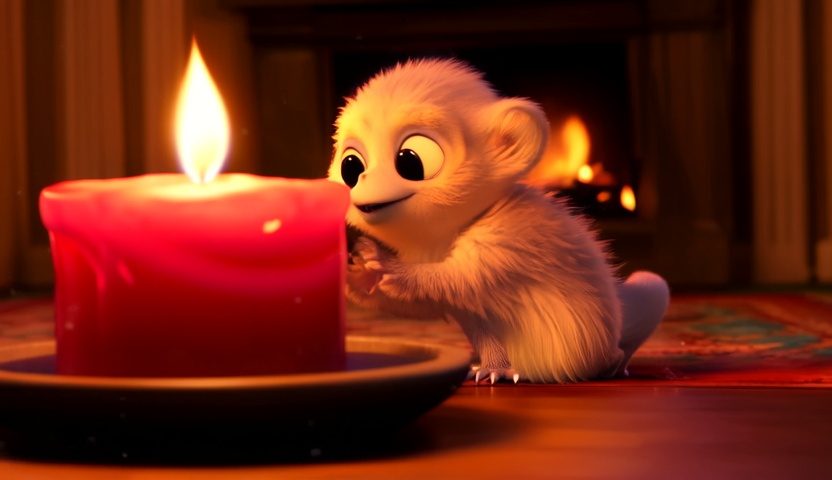

In [13]:
import os 
import cv2
from IPython.display import Image, display, clear_output
import time
import torch
from einops import rearrange


def view_video_numpy(video, prompt):
    """
    video should be in the shape of (B, T, C, H, W)"""
    fps = 1/16 #16fps

    # video = video.reshape(video.shape[0], video.shape[1], video.shape[3], video.shape[4], video.shape[2]) # [b,T,H,W,C]
    video = rearrange(video, 'b t c h w -> b t h w c') # [b,T,H,W,C]

    video_frame_list = video[0].cpu().numpy()
    # print(video_frame_list.shape)
    
    print(video_frame_list.shape)
    for video_frame in video_frame_list:
        # print(video_frame.shape)
        clear_output(wait=True)
        rgb_frame = cv2.cvtColor(video_frame,cv2.COLOR_BGR2RGB)
        # rgb_frame = video_frame
        _, encoded_image = cv2.imencode('.jpeg',rgb_frame)
        display(Image(data=encoded_image.tobytes()))
        # print(prompt)
        time.sleep(fps)


view_video_numpy(vid_from_latent, "text")
# view_video_numpy(video, "text")
# torch.save(video,"sf_long_video_sink3_local12.mp4")
# view_video_numpy(torch.load("sf_long_video_sink3_local12.mp4"), "text")


# view_video_numpy(video, "text")
# torch.save(video,"sf_long_video_sink0_localall.mp4")
# view_video_numpy(torch.load("sf_long_video_sink0_localall.mp4"), "text")

# view_video_numpy(video, "text")
# view_video_numpy(vid_from_latent, "text")

video = rearrange(vid_from_latent, 'b t c h w -> b t h w c') # [b,T,H,W,C]
video = video.squeeze(0).cpu().numpy()

# write_video("sf_long_video_sink3_local12.mp4", video, fps=16)
# write_video("sf_long_video_sink0_local21.mp4", video, fps=16)

# write_video("cf_long_video_sink0_local21.mp4", video, fps=16)
# write_video("cf_long_video_sink3_local12.mp4", video, fps=16)


In [14]:
# break
video_latent_save = rearrange(vid_from_latent, 'b t c h w -> b t h w c') # [b,T,H,W,C]
video_latent_save = video_latent_save.squeeze(0).cpu().numpy()
# write_video("cf_tokyo_video_bidirectional_gen.mp4", video_latent_save, fps=16)
# write_video("cf_tokyo_video_causal_gen.mp4", video_latent_save, fps=16)
write_video("cf_monster_video_causal_gen.mp4", video_latent_save, fps=16)


/shared/miniconda3/envs/self_forcing/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
